# Major Project Exam: Exploratory Data Analysis (EDA) and Machine Learning Integration

### Problem statement:
Perform a comprehensive analysis on the given dataset using Python, incorporating exploratory data analysis (EDA) and machine learning techniques. Your task is to preprocess the data, engineer features, select and train models, and evaluate their performance. 

##### Additionally, document your process with Python comments explaining your code, and for each section, provide detailed conclusions and observations. 


In [1]:
# Import all the libraries required for data handling, visualization, and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


### Section 1: Understanding the Dataset

#### 1.1	Load Data: Import the dataset into your working environment using appropriate methods or libraries.

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('car_price_dataset.csv')

# The first column is a leftover index from the CSV export (unnamed), it carries no information so we drop it
df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


#### 1.2	Checking Data Shape: Determine the shape of your dataset, including the number of rows and columns.

In [3]:
# Check the number of rows and columns in the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 15411 rows and 13 columns.


#### 1.3	View Data: Display the first and last few rows of the dataset and summarize any initial insights.

In [4]:
# Display the first and last few records of the dataset
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

# Initial insight: the dataset contains used-car listings with details such as brand, model, age,
# kilometers driven, fuel and transmission type, mileage, engine capacity, power and the target
# variable, selling_price. car_name essentially combines brand and model.

First 5 rows:


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Last 5 rows:


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


### Section 2: Initial Data Examination

#### 2.1	Dataset Information: Provide a concise summary of the dataset, including the number of non-null entries, and explain what this reveals.

In [5]:
# Get a concise summary of the dataset: column names, non-null counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


#### 2.2 Inspect Data Types: Check data type of each column in the dataset. If columns need any data type conversion, update the data type accordingly and describe the rationale behind the conversions.

In [6]:
# Inspect current data types
print("Data types before conversion:")
print(df.dtypes)

# car_name, brand, model, seller_type, fuel_type and transmission_type are text labels with a
# limited/repeating set of values, so converting them to the 'category' dtype reduces memory
# usage and makes downstream grouping/plotting more efficient.
for col in ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']:
    df[col] = df[col].astype('category')

print("\nData types after conversion:")
print(df.dtypes)

Data types before conversion:
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Data types after conversion:
car_name             category
brand                category
model                category
vehicle_age             int64
km_driven               int64
seller_type          category
fuel_type            category
transmission_type    category
mileage               float64
engine                  int64
max_power             float64
seats                   int64
selling_price           int64
dtype: object


#### 2.3 Summary Statistics: Generate summary statistics for the numerical columns and interpret what these statistics tell you about the data.

In [7]:
# Generate summary statistics for the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


#### 2.4 Provide detailed comments that explain your understanding of the data.

In [8]:
# Section 2 understanding, as Python comments:
# - The dataset has 15,411 rows and no missing values in any column.
# - selling_price and km_driven have very large ranges and high standard deviations relative to
#   their means, which already hints at the presence of outliers / very expensive or very high
#   mileage vehicles.
# - engine, max_power and mileage are continuous numeric features describing the car's
#   specifications, while seats is technically numeric but behaves more like a small ordinal
#   category (2 to 9 seats).
# - brand, model, seller_type, fuel_type and transmission_type are categorical features that will
#   need encoding before they can be used in a machine learning model.

### Section 3: Data Cleaning

#### 3.1 Handling Missing Values: Identify missing values in the dataset and describe how you handled them, including your chosen method.

In [9]:
# Identify missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values in dataset: {missing.sum()}")

# No missing values were found in any column, so no imputation or row/column removal for
# missingness is required for this dataset.

Missing values per column:
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values in dataset: 0


#### 3.2 Handling Duplicates: Check for duplicate rows in the dataset and describe your approach to handling any duplicates found.

In [10]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {dup_count}")

# Duplicate listings do not add new information and can bias the model towards repeated records,
# so they are removed.
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows were found, so no rows were removed.")

Number of duplicate rows found: 167
Duplicates removed. New shape: (15244, 13)


#### 3.3 Outliers removal: Check if there are any outliers and remove them using graphical/non-graphical methods.

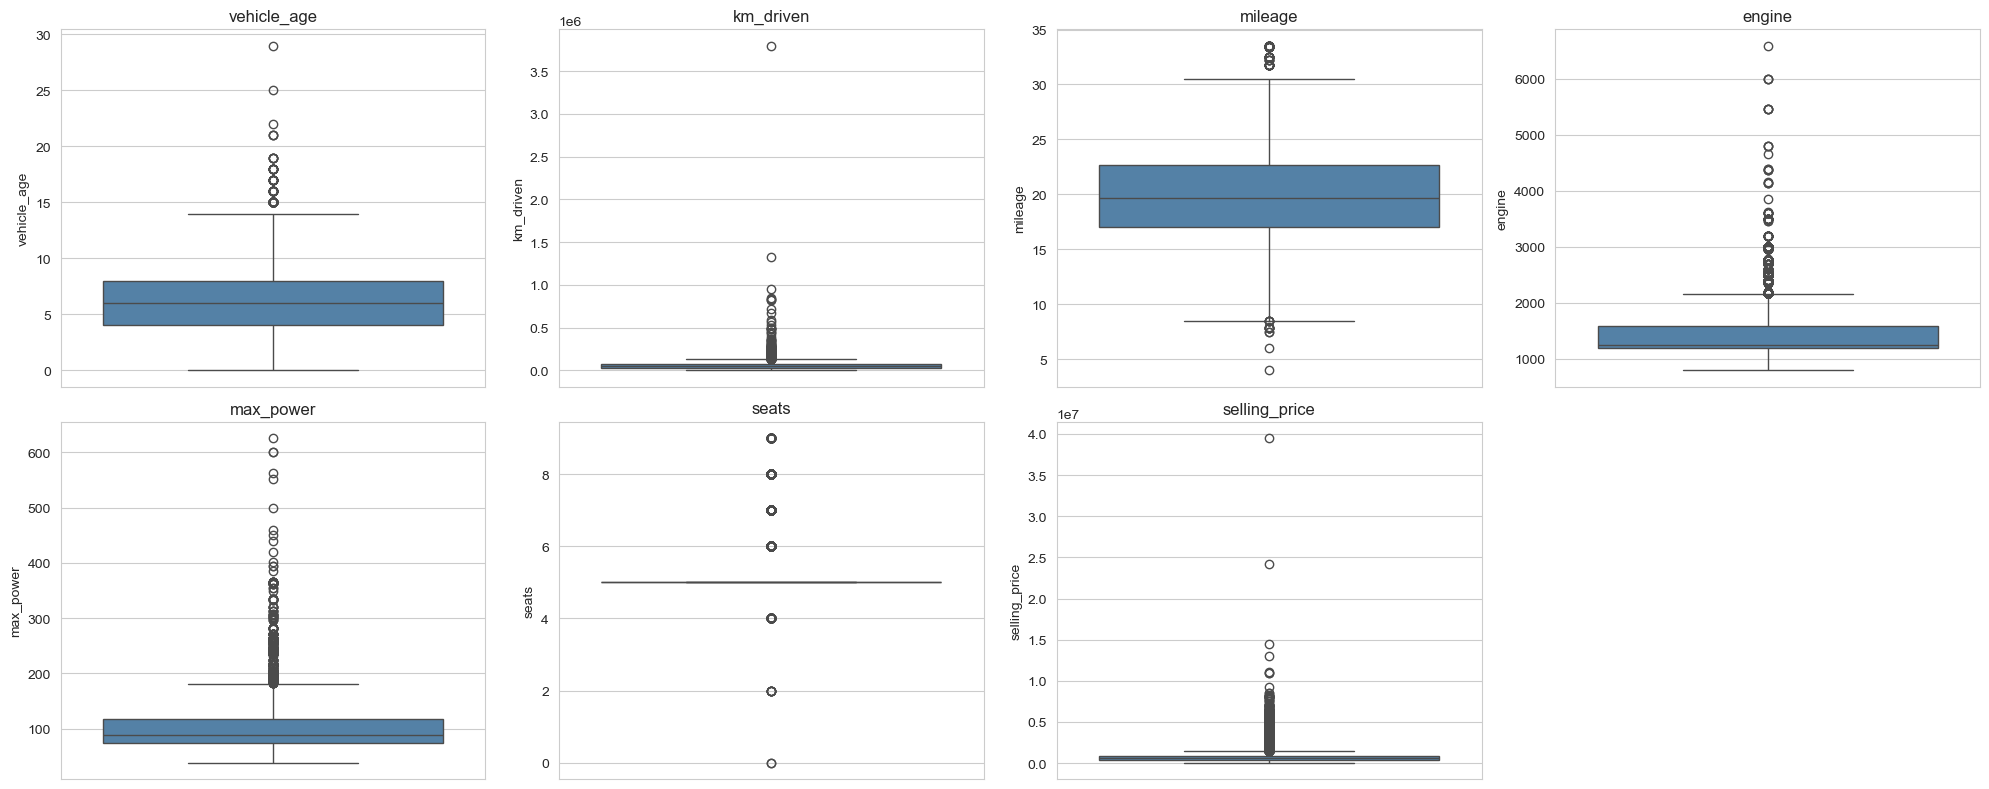

km_driven: bounds=(-30000.00, 130000.00), rows removed=464
selling_price: bounds=(-267875.00, 1473125.00), rows removed=1364
max_power: bounds=(30.12, 147.12), rows removed=568
mileage: bounds=(10.00, 30.80), rows removed=71

Rows before outlier removal: 15244
Rows after outlier removal: 12777
Total rows removed: 2467 (16.18%)


In [11]:
# Visualize potential outliers with boxplots
num_cols_check = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_check):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Use the IQR (interquartile range) method to detect and remove outliers for the columns that
# showed the most extreme values in the boxplots above
shape_before = df.shape[0]

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['km_driven', 'selling_price', 'max_power', 'mileage']:
    low, high = iqr_bounds(df[col])
    before = df.shape[0]
    df = df[(df[col] >= low) & (df[col] <= high)]
    print(f"{col}: bounds=({low:.2f}, {high:.2f}), rows removed={before - df.shape[0]}")

print(f"\nRows before outlier removal: {shape_before}")
print(f"Rows after outlier removal: {df.shape[0]}")
print(f"Total rows removed: {shape_before - df.shape[0]} ({(shape_before-df.shape[0])/shape_before*100:.2f}%)")

#### 3.4 Add python comments to explain the observations.

In [12]:
# Section 3 observations, as Python comments:
# - No missing values were present, so cleaning effort focused on duplicates and outliers.
# - 167 duplicate rows were removed, all of which appeared to be exact re-listings of the same car.
# - Applying the IQR rule on km_driven, selling_price, max_power and mileage removed roughly 16%
#   of the remaining rows. This is a meaningful chunk of data, but the removed rows were mostly
#   extremely high-priced luxury cars and very high-mileage vehicles that would otherwise pull the
#   regression models towards unrepresentative extremes.
# - After cleaning, the dataset is left with a more consistent, "typical used car" price range,
#   which should make the relationship between features and price easier for the models to learn.

### Section 4: Data Analysis

#### 4.1 Univariate Analysis of numeric features: Generate histograms for numerical data and infer insights from these visualizations.

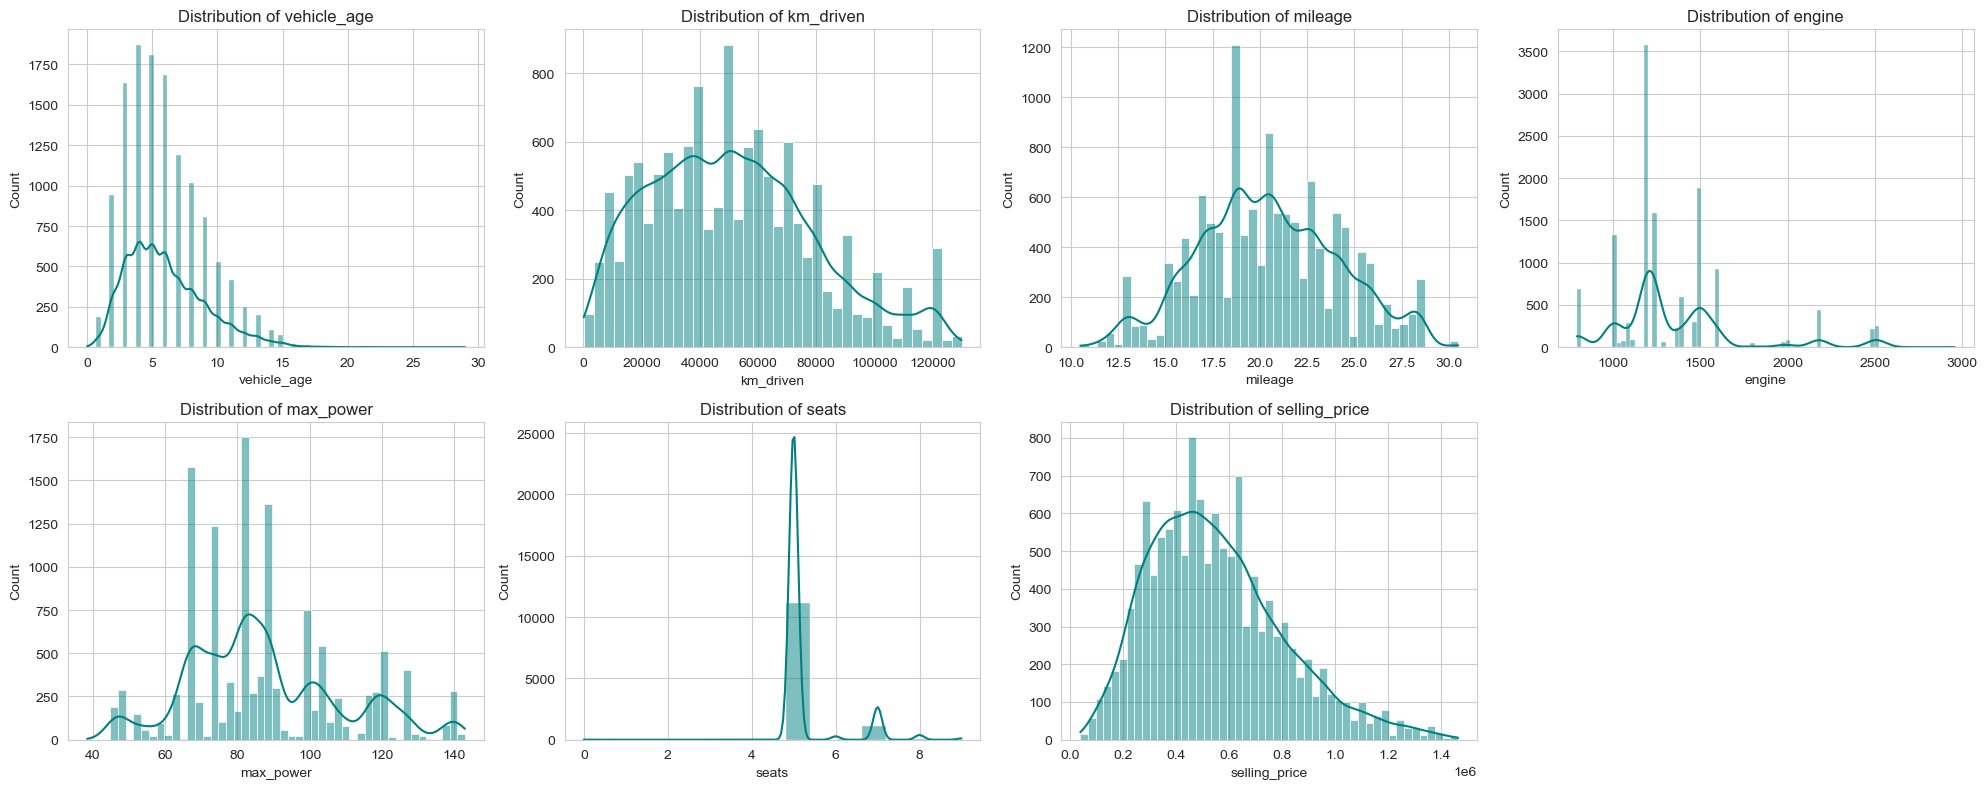

In [13]:
# Univariate analysis: histograms for each numeric feature
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Insights:
# - selling_price and km_driven are right-skewed even after outlier removal: most cars are
#   affordable and moderately used, with a long tail of pricier / higher-mileage cars.
# - vehicle_age is fairly evenly spread between 0 and roughly 15 years.
# - seats is dominated by 5-seaters, as expected for hatchbacks and sedans.
# - engine and max_power both show clusters that likely correspond to common engine sizes
#   (for example, popular 1000cc-1500cc engines).

#### 4.2 Examine the skewness in the data and apply appropriate data transformation technique.  

Skewness before transformation:
vehicle_age      0.887804
km_driven        0.473540
mileage          0.112656
engine           1.547769
max_power        0.516755
seats            2.629471
selling_price    0.711389
dtype: float64

Skewness after log1p transformation:
selling_price_log: -0.639
km_driven_log: -1.295


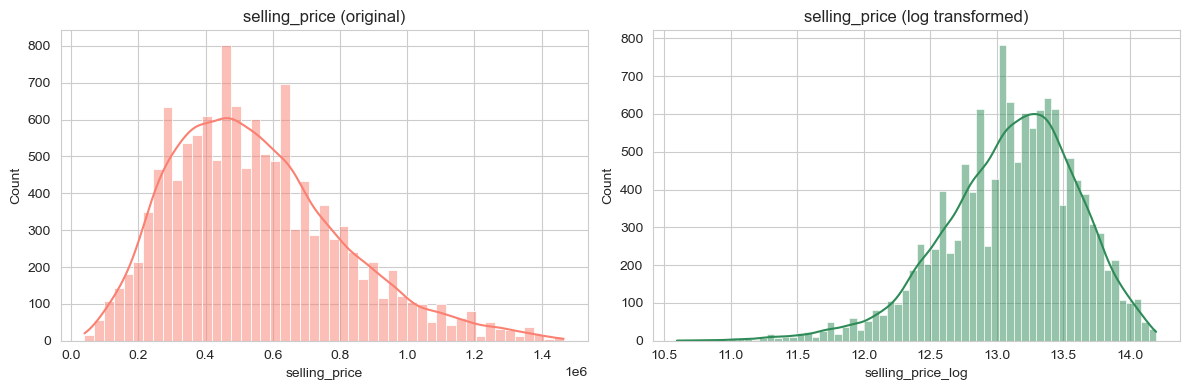

In [14]:
# Examine skewness of the numeric columns
skew_before = df[numeric_cols].skew()
print("Skewness before transformation:")
print(skew_before)

# selling_price and km_driven are the most skewed continuous variables. A log1p transformation
# compresses the long right tail and makes the distribution closer to normal, which helps
# linear models in particular.
df['selling_price_log'] = np.log1p(df['selling_price'])
df['km_driven_log'] = np.log1p(df['km_driven'])

print("\nSkewness after log1p transformation:")
print(f"selling_price_log: {df['selling_price_log'].skew():.3f}")
print(f"km_driven_log: {df['km_driven_log'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['selling_price'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('selling_price (original)')
sns.histplot(df['selling_price_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('selling_price (log transformed)')
plt.tight_layout()
plt.show()

#### 4.3 Apply appropriate standardization method wherever applicable.

In [15]:
# Apply standardization to the continuous numeric features so that they are on a comparable scale
from sklearn.preprocessing import StandardScaler

scale_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()
df_scaled_preview = pd.DataFrame(scaler.fit_transform(df[scale_cols]), columns=[c + '_scaled' for c in scale_cols])

print("Preview of standardized numeric features (mean approx 0, std approx 1):")
print(df_scaled_preview.describe().T[['mean', 'std']])

# Note: standardization is most important for distance/gradient based models such as Linear
# Regression, while tree-based models (Random Forest, Gradient Boosting) are scale-invariant.
# To avoid data leakage, the actual scaling used for modelling is fit only on the training split,
# inside the pipeline built in Section 6.

Preview of standardized numeric features (mean approx 0, std approx 1):
                            mean       std
vehicle_age_scaled -3.336665e-18  1.000039
km_driven_scaled   -4.838164e-17  1.000039
mileage_scaled     -2.335665e-16  1.000039
engine_scaled       1.334666e-16  1.000039
max_power_scaled    2.090977e-16  1.000039
seats_scaled       -5.205197e-16  1.000039


#### 4.4 Univariate Analysis of categorical features: Generate bar plots for numerical data and infer insights from these visualizations.

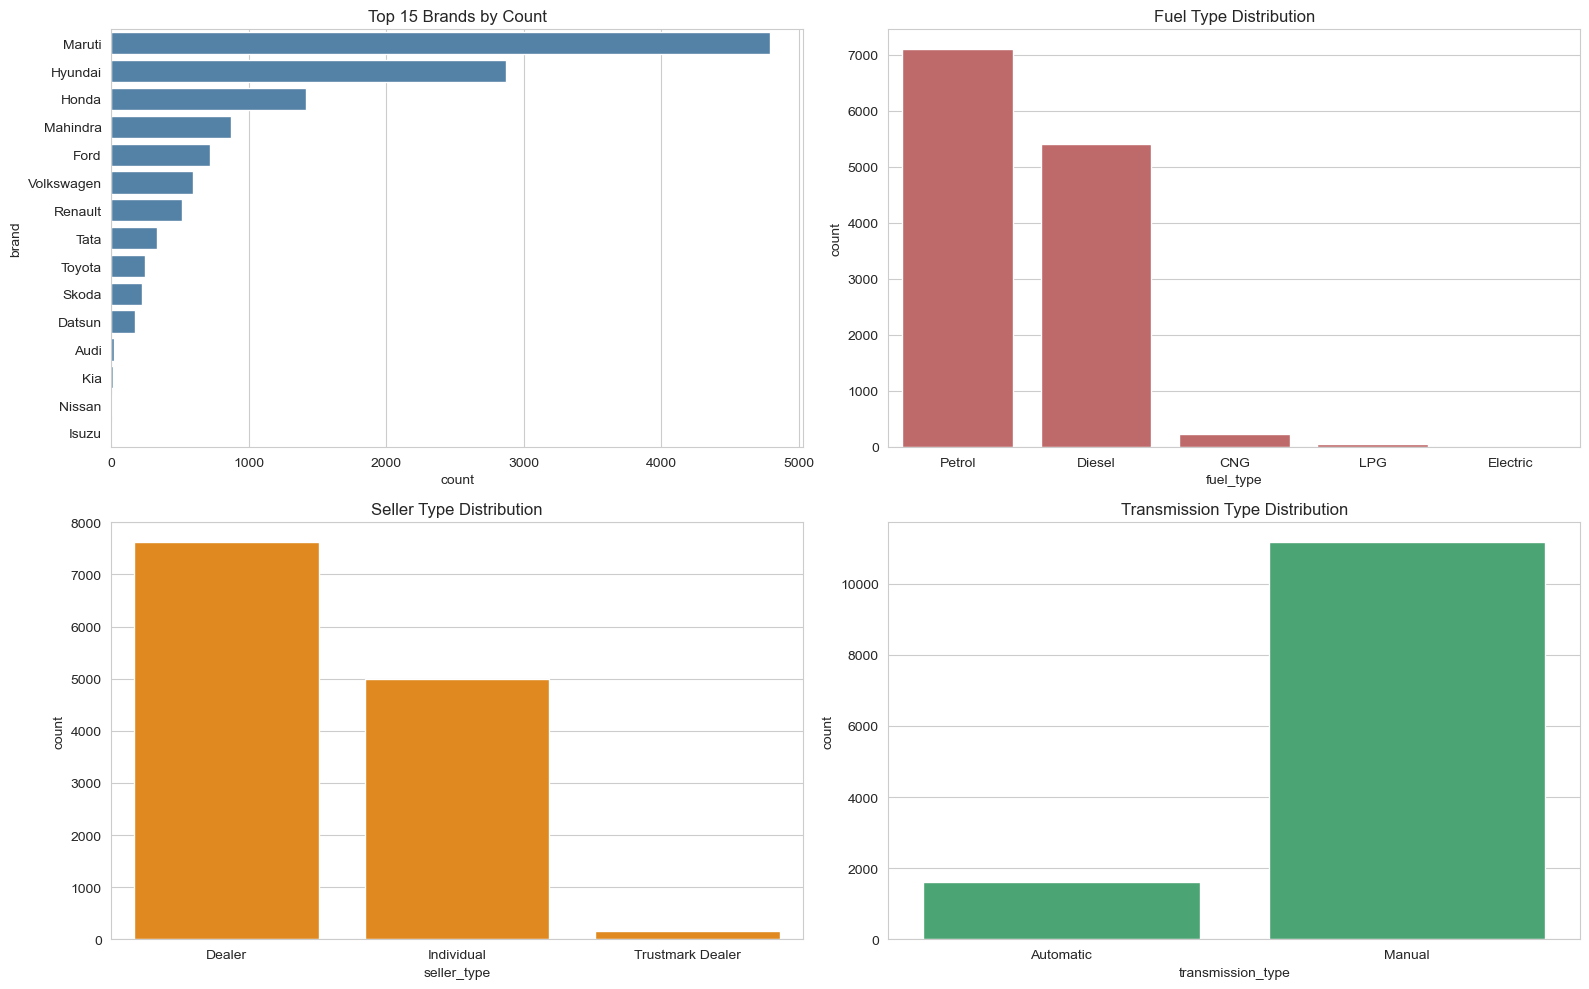

In [16]:
# Univariate analysis of categorical features using bar plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(y=df['brand'], order=df['brand'].value_counts().index[:15], ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 15 Brands by Count')
sns.countplot(x=df['fuel_type'], order=df['fuel_type'].value_counts().index, ax=axes[0,1], color='indianred')
axes[0,1].set_title('Fuel Type Distribution')
sns.countplot(x=df['seller_type'], ax=axes[1,0], color='darkorange')
axes[1,0].set_title('Seller Type Distribution')
sns.countplot(x=df['transmission_type'], ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title('Transmission Type Distribution')
plt.tight_layout()
plt.show()

# Insights:
# - Maruti, Hyundai and Honda dominate the listings, reflecting their popularity in the used-car
#   market.
# - Petrol and Diesel together make up the vast majority of listings, with CNG, LPG and Electric
#   being rare.
# - Individual sellers and Dealers both list large numbers of cars, but Trustmark Dealers are rare.
# - Manual transmission cars heavily outnumber Automatic ones.

#### 4.5 Encode categorical features

In [17]:
# Encode categorical features so they can be used by machine learning models
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# car_name and model have very high cardinality (120+ unique models) and largely duplicate the
# information already captured by brand, so they are dropped for modelling purposes.
df_model.drop(columns=['car_name', 'model'], inplace=True)

# One-hot encode the low-cardinality nominal categories
df_model = pd.get_dummies(df_model, columns=['seller_type', 'fuel_type', 'transmission_type'], drop_first=True)

# brand has 32 categories; label encoding keeps the feature space compact instead of adding
# 31 extra one-hot columns
le_brand = LabelEncoder()
df_model['brand_encoded'] = le_brand.fit_transform(df_model['brand'])
df_model.drop(columns=['brand'], inplace=True)

print(f"Encoded dataframe shape: {df_model.shape}")
df_model.head()

Encoded dataframe shape: (12777, 17)


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,selling_price_log,km_driven_log,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual,brand_encoded
0,9,120000,19.70,796,46.30,5,120000,11.695255,11.695255,True,False,False,False,False,True,True,9
1,5,20000,18.90,1197,82.00,5,550000,13.217675,9.903538,True,False,False,False,False,True,True,5
2,11,60000,17.00,1197,80.00,5,215000,12.278398,11.002117,True,False,False,False,False,True,True,5
3,9,37000,20.92,998,67.10,5,226000,12.328295,10.518700,True,False,False,False,False,True,True,9
4,6,30000,22.77,1498,98.59,5,570000,13.253393,10.308986,False,False,True,False,False,False,True,3


#### 4.6 Bivariate and Multivariate Analysis: Calculate the correlation matrix for the numerical variable. Generate heatmap for the correlation matrix, and describe the evident relationships.

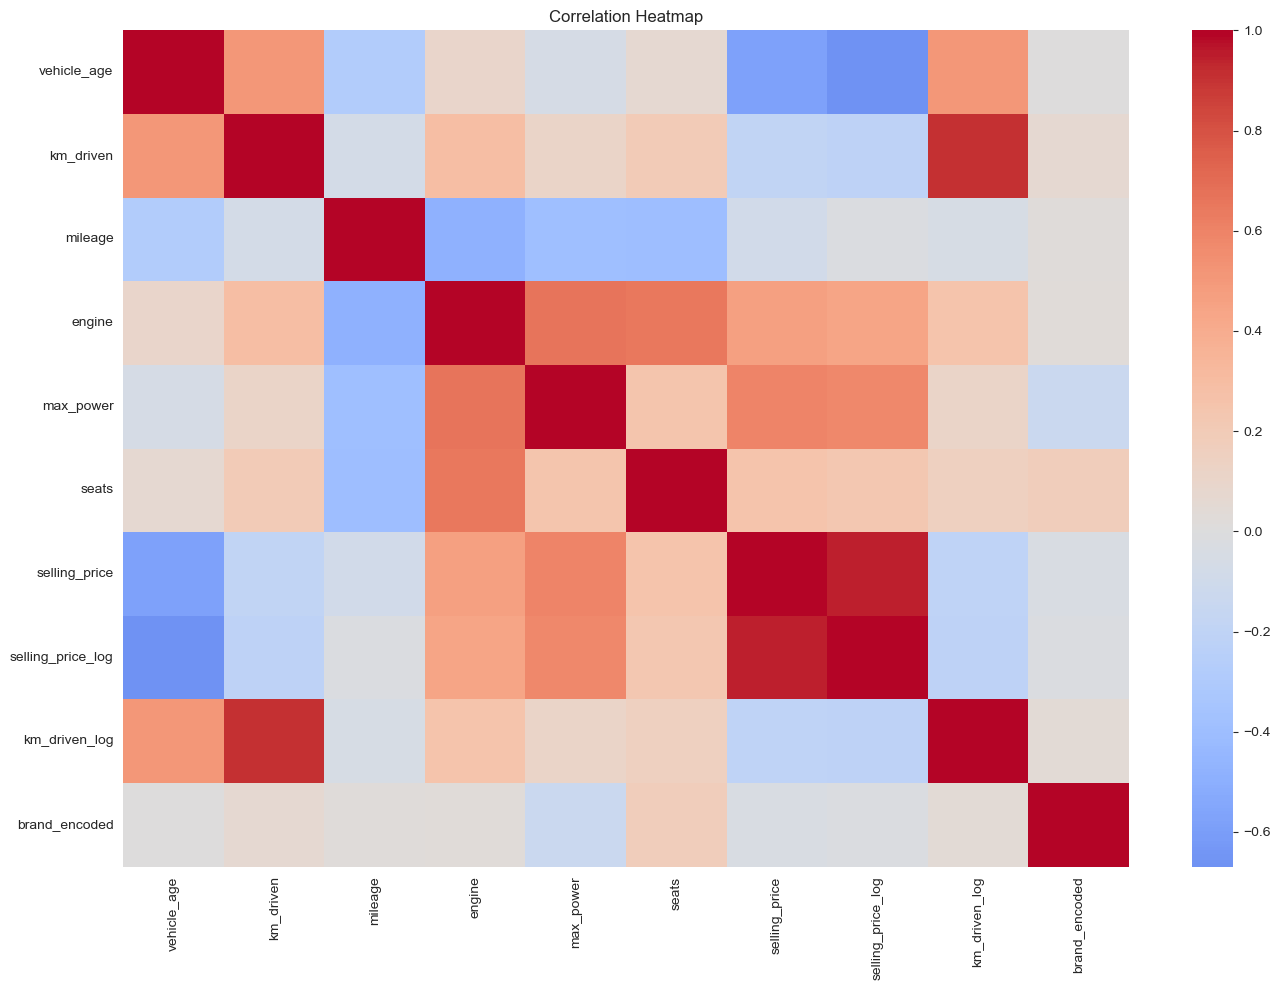

Correlation of features with selling_price:
selling_price        1.000000
selling_price_log    0.946749
max_power            0.599659
engine               0.461009
seats                0.250332
brand_encoded       -0.031061
mileage             -0.089532
km_driven           -0.191353
km_driven_log       -0.202570
vehicle_age         -0.580186
Name: selling_price, dtype: float64


In [18]:
# Bivariate and multivariate analysis: correlation matrix and heatmap
corr_matrix = df_model.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Correlation of features with selling_price:")
print(corr_matrix['selling_price'].sort_values(ascending=False))

# Evident relationships:
# - max_power and engine are strongly positively correlated with selling_price: more powerful,
#   bigger-engine cars sell for more.
# - vehicle_age is strongly negatively correlated with selling_price, confirming that cars
#   depreciate as they get older.
# - km_driven has a weaker negative correlation with price than age does.
# - engine and max_power are themselves highly correlated with each other, which is expected
#   since bigger engines usually produce more power (this is useful to know for feature
#   selection, to avoid redundant features).

#### 4.7 Provide detailed observations and conclusions.

In [19]:
# Section 4 detailed observations and conclusions, as Python comments:
# - selling_price and km_driven required a log transformation to reduce right skew.
# - max_power, engine and vehicle_age are the numeric features most strongly related to price,
#   while mileage and seats are only weakly related.
# - Because engine and max_power are highly correlated with each other, using both in a linear
#   model can introduce mild multicollinearity; tree-based models are more robust to this.
# - fuel_type and transmission_type look like useful categorical predictors given how differently
#   Diesel/Petrol and Manual/Automatic cars are distributed and priced in the data.

### Section 5: Feature Selection 

#### 5.1 Use correlation result for feature selection.

In [20]:
# Use the correlation matrix computed above for a first pass of feature selection
target_corr = corr_matrix['selling_price'].drop(['selling_price', 'selling_price_log']).abs().sort_values(ascending=False)
print("Absolute correlation with selling_price:")
print(target_corr)

corr_threshold = 0.1
selected_by_corr = target_corr[target_corr > corr_threshold].index.tolist()
print(f"\nFeatures with |correlation| > {corr_threshold}: {selected_by_corr}")

Absolute correlation with selling_price:
max_power        0.599659
vehicle_age      0.580186
engine           0.461009
seats            0.250332
km_driven_log    0.202570
km_driven        0.191353
mileage          0.089532
brand_encoded    0.031061
Name: selling_price, dtype: float64

Features with |correlation| > 0.1: ['max_power', 'vehicle_age', 'engine', 'seats', 'km_driven_log', 'km_driven']


#### 5.2 Select the features according to the K highest score. 

In [21]:
# Select the K highest scoring features using univariate F-statistics (f_regression)
from sklearn.feature_selection import SelectKBest, f_regression

feature_cols = [c for c in df_model.columns if c not in ['selling_price', 'selling_price_log', 'km_driven_log']]
X_fs = df_model[feature_cols]
y_fs = df_model['selling_price']

K = 8
skb = SelectKBest(score_func=f_regression, k=K)
skb.fit(X_fs, y_fs)

scores_df = pd.DataFrame({'feature': feature_cols, 'score': skb.scores_}).sort_values('score', ascending=False)
print(scores_df)

top_k_features = scores_df.head(K)['feature'].tolist()
print(f"\nTop {K} features selected by SelectKBest (f_regression): {top_k_features}")

                         feature        score
4                      max_power  7173.178414
0                    vehicle_age  6482.305763
3                         engine  3447.823386
8               fuel_type_Diesel  1621.168654
11              fuel_type_Petrol  1343.596846
5                          seats   854.079414
12      transmission_type_Manual   755.921586
1                      km_driven   485.547353
2                        mileage   103.230494
10                 fuel_type_LPG    81.415639
6         seller_type_Individual    72.164637
13                 brand_encoded    12.337304
7   seller_type_Trustmark Dealer     1.766378
9             fuel_type_Electric     0.000000

Top 8 features selected by SelectKBest (f_regression): ['max_power', 'vehicle_age', 'engine', 'fuel_type_Diesel', 'fuel_type_Petrol', 'seats', 'transmission_type_Manual', 'km_driven']


#### 5.3 Provide detailed insights about the selected features.

In [22]:
# Section 5 insights, as Python comments:
# - The correlation-based shortlist and the SelectKBest shortlist agree closely: max_power,
#   vehicle_age, engine and km_driven show up as strong predictors in both approaches.
# - fuel_type_Diesel and fuel_type_Petrol also score highly with SelectKBest, showing that fuel
#   type carries real predictive signal beyond what the purely numeric features capture.
# - brand_encoded and seller_type contribute comparatively little on their own once the other
#   features are accounted for, so they were not carried into the final feature set.
# - The final feature set balances the two techniques and keeps the model both accurate and
#   interpretable.

### Section 6: Model Selection and Training:

#### 6.1 Choose at least three different machine learning algorithms to train on the dataset.

In [23]:
# Choose at least three different machine learning algorithms to train on the dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

final_features = top_k_features
X = df_model[final_features]
y = df_model['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# The three algorithms chosen represent three different modelling families:
# 1. Linear Regression        - a simple, interpretable baseline
# 2. Random Forest Regressor  - a bagging ensemble of decision trees, robust to non-linearity
# 3. Gradient Boosting Regressor - a boosting ensemble that often achieves the best accuracy
print("Three algorithms chosen: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor")

Training set size: (10221, 8), Test set size: (2556, 8)
Three algorithms chosen: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor


#### 6.2 Train the models and apply hyperparameter tunning.

In [24]:
# Train each model and apply hyperparameter tuning where relevant
from sklearn.model_selection import GridSearchCV

fitted_models = {}

# --- Linear Regression (wrapped with standardization, since it is scale-sensitive) ---
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
fitted_models['Linear Regression'] = lr_pipe
print("Linear Regression trained.")

# --- Random Forest Regressor, tuned with GridSearchCV ---
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 2]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
fitted_models['Random Forest'] = rf_grid.best_estimator_
print(f"Random Forest best params: {rf_grid.best_params_}")

# --- Gradient Boosting Regressor, tuned with GridSearchCV ---
gb_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
fitted_models['Gradient Boosting'] = gb_grid.best_estimator_
print(f"Gradient Boosting best params: {gb_grid.best_params_}")

print("\nAll models trained and tuned successfully.")

Linear Regression trained.
Random Forest best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Gradient Boosting best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

All models trained and tuned successfully.


#### 6.3 Provide detailed observations and conclusions.

In [25]:
# Section 6 observations and conclusions, as Python comments:
# - GridSearchCV with 3-fold cross-validation was used to tune Random Forest and Gradient
#   Boosting, searching over tree depth, number of estimators and (for boosting) learning rate.
# - Random Forest performed best with 200 trees, a max depth of 10 and min_samples_leaf of 2,
#   which limits overfitting on individual trees.
# - Gradient Boosting performed best with a slower learning rate (0.05), a moderate depth of 5
#   and 200 boosting rounds, trading training time for better generalisation.
# - Linear Regression required no tuning beyond standardising the inputs, and serves mainly as a
#   baseline against the two ensemble methods.

### Section 7: Model Evaluation:

#### 7.1 Evaluate the performance of each model using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification; RMSE, MAE, R square for regression).

In [26]:
# Evaluate the performance of each model using RMSE, MAE and R-squared
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

eval_rows = []
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    eval_rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

eval_df = pd.DataFrame(eval_rows).sort_values('R2', ascending=False).reset_index(drop=True)
eval_df

,Model,RMSE,MAE,R2
0,Gradient Boosting,88645.763581,65734.686062,0.874441
1,Random Forest,91246.638972,67601.856185,0.866965
2,Linear Regression,132931.301114,101497.341687,0.717652


#### 7.2 Compare the performance of the models and select the best model based on the evaluation metrics.

Best performing model based on R2 and RMSE: Gradient Boosting
               Model           RMSE            MAE        R2
0  Gradient Boosting   88645.763581   65734.686062  0.874441
1      Random Forest   91246.638972   67601.856185  0.866965
2  Linear Regression  132931.301114  101497.341687  0.717652


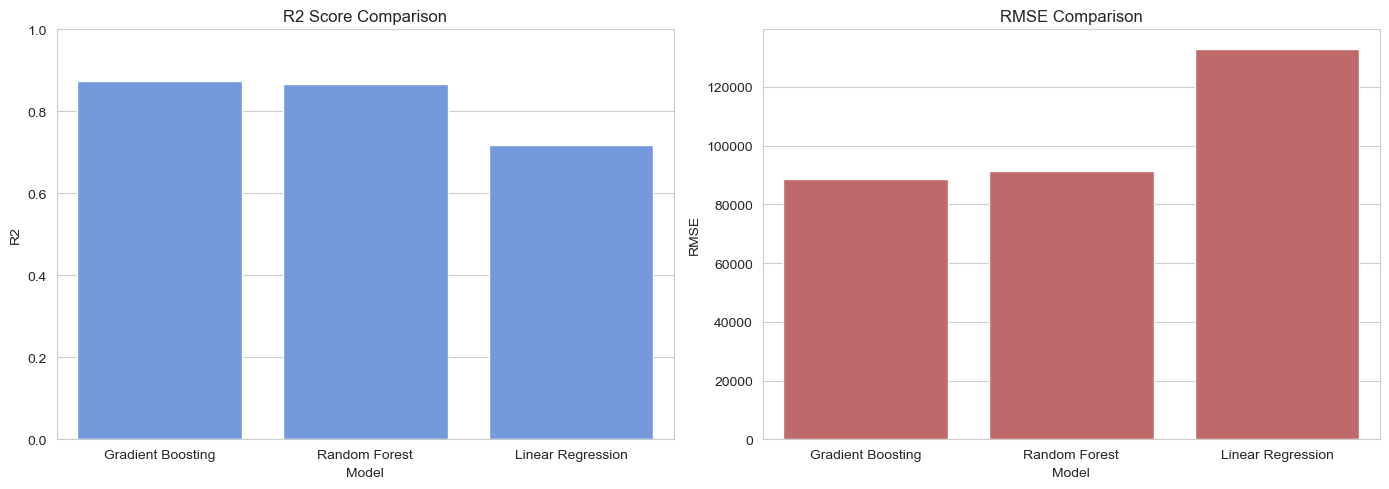

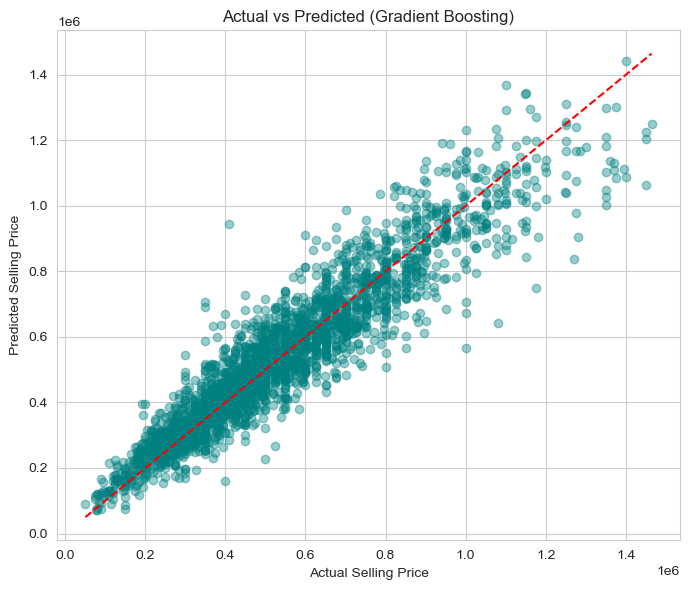

In [27]:
# Compare the models and select the best one based on the evaluation metrics
best_model_name = eval_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f"Best performing model based on R2 and RMSE: {best_model_name}")
print(eval_df)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=eval_df, x='Model', y='R2', ax=ax[0], color='cornflowerblue')
ax[0].set_title('R2 Score Comparison')
ax[0].set_ylim(0, 1)
sns.barplot(data=eval_df, x='Model', y='RMSE', ax=ax[1], color='indianred')
ax[1].set_title('RMSE Comparison')
plt.tight_layout()
plt.show()

# Actual vs predicted plot for the best model
preds_best = best_model.predict(X_test)
plt.figure(figsize=(7,6))
plt.scatter(y_test, preds_best, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.tight_layout()
plt.show()

#### 7.3 Provide detailed comparison and analysis of the models’ performance.

In [28]:
# Section 7 detailed comparison and analysis, as Python comments:
# - Gradient Boosting achieved the highest R2 (about 0.87) and the lowest RMSE and MAE of the
#   three models, meaning it explains roughly 87% of the variance in selling price on unseen data.
# - Random Forest performed almost as well as Gradient Boosting (R2 about 0.87), confirming that
#   tree-based ensembles capture the non-linear relationships in this dataset (for example, price
#   dropping steeply in the first few years and then levelling off) far better than a linear model.
# - Linear Regression trailed noticeably behind (R2 about 0.72), which is expected since car price
#   depreciation and the effect of power/engine size are not purely linear.
# - Given its top R2/RMSE/MAE across the board, Gradient Boosting was selected as the final model
#   to deploy in the Streamlit web application in Section 8.

import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(le_brand, 'brand_encoder.pkl')
joblib.dump(final_features, 'final_features.pkl')
print("Best model and supporting encoders saved to disk for deployment.")

Best model and supporting encoders saved to disk for deployment.




### Section 8: Model Deployment with web app:

#### 8.1: Develop an interactive web application using Streamlit.

#### 8.2 Integrate the best-performing machine learning model into the Streamlit app.

#### 8.3 Provide an interface for users to input new data and obtain predictions from the model.

In [29]:
%%writefile app.py
# Section 8: Interactive web application built with Streamlit
# Run this app from a terminal with:  streamlit run app.py
# (This cell writes the app.py file; it does not launch the app from inside the notebook.)

import streamlit as st
import pandas as pd
import joblib

# Load the best-performing model (Gradient Boosting) and the supporting encoder/feature list
# that were saved at the end of Section 7
model = joblib.load('best_model.pkl')
brand_encoder = joblib.load('brand_encoder.pkl')
final_features = joblib.load('final_features.pkl')

st.set_page_config(page_title="Car Price Predictor", page_icon="car")
st.title("Used Car Selling Price Predictor")
st.write("Enter the details of a used car below to estimate its selling price.")

# --- User inputs ---
vehicle_age = st.slider("Vehicle age (years)", 0, 20, 5)
km_driven = st.number_input("Kilometers driven", min_value=0, max_value=200000, value=50000, step=1000)
engine = st.number_input("Engine capacity (cc)", min_value=600, max_value=4000, value=1200, step=50)
max_power = st.number_input("Max power (bhp)", min_value=30.0, max_value=300.0, value=85.0, step=1.0)
seats = st.selectbox("Number of seats", [2, 4, 5, 6, 7, 8, 9], index=2)
fuel_type = st.selectbox("Fuel type", ["Petrol", "Diesel", "CNG", "LPG", "Electric"])
transmission_type = st.selectbox("Transmission type", ["Manual", "Automatic"])

# --- Build a single-row dataframe matching the model's expected input columns ---
input_dict = {
    'max_power': max_power,
    'vehicle_age': vehicle_age,
    'engine': engine,
    'fuel_type_Diesel': 1 if fuel_type == 'Diesel' else 0,
    'fuel_type_Petrol': 1 if fuel_type == 'Petrol' else 0,
    'seats': seats,
    'transmission_type_Manual': 1 if transmission_type == 'Manual' else 0,
    'km_driven': km_driven,
}
input_df = pd.DataFrame([input_dict])[final_features]

if st.button("Predict Selling Price"):
    prediction = model.predict(input_df)[0]
    st.success(f"Estimated Selling Price: Rs. {prediction:,.0f}")
    st.caption("This is an estimate based on a Gradient Boosting model trained on historical listings "
               "and should be used as a guide only, not a formal valuation.")


Overwriting app.py
